In [1]:
%matplotlib inline
import os, sys

ROOT = os.path.expanduser('~/QIAO0042/models/acv/facemask/')
os.chdir(ROOT)

print('Working dir:', os.getcwd())

Working dir: /scratch-share/QIAO0042/models/acv/facemask


In [1]:
import wandb
import matplotlib.pyplot as plt
from IPython.display import display

WANDB_ENTITY  = '584832452-nanyang-technological-university-singapore'
WANDB_PROJECT = 'face-parsing-unet'

# ── Candidate key names (checked in order) ───────────────────────────────────
_LOSS_CANDIDATES    = ['train/loss', 'train_loss', 'loss']
_VAL_F1_CANDIDATES  = ['val/macro_f1', 'val/f1', 'val_f1', 'val/macro_F1']
_VAL_ACC_CANDIDATES = ['val/acc', 'val_acc', 'val/accuracy']
_LR_CANDIDATES      = ['lr', 'learning_rate', 'train/lr']


def _pick(columns, candidates):
    for c in candidates:
        if c in columns:
            return c
    return None


def fetch_history(run_id):
    api  = wandb.Api()
    path = run_id if '/' in run_id else f'{WANDB_ENTITY}/{WANDB_PROJECT}/{run_id}'
    run  = api.run(path)

    df   = run.history(samples=10_000, pandas=True)
    cols = set(df.columns)

    print(f"Run    : {run.name}  ({run.id})  |  state: {run.state}")
    print(f"Columns: {sorted(cols)}")

    loss_col    = _pick(cols, _LOSS_CANDIDATES)
    val_f1_col  = _pick(cols, _VAL_F1_CANDIDATES)
    val_acc_col = _pick(cols, _VAL_ACC_CANDIDATES)
    lr_col      = _pick(cols, _LR_CANDIDATES)

    if loss_col is None:
        raise KeyError(
            f"No loss column found in run '{run.name}'.\n"
            f"  Available columns: {sorted(cols)}\n"
            f"  Searched for: {_LOSS_CANDIDATES}"
        )

    print(f"Mapped : train_loss←'{loss_col}'  "
          f"val_f1←'{val_f1_col}'  "
          f"val_acc←'{val_acc_col}'  "
          f"lr←'{lr_col}'")

    keep = {c for c in [loss_col, val_f1_col, val_acc_col, lr_col] if c}
    sub  = df[list(keep)].dropna(subset=[loss_col])

    history = {'train_loss': sub[loss_col].tolist()}
    history['val_f1']  = sub[val_f1_col].tolist()  if val_f1_col  else None
    history['val_acc'] = sub[val_acc_col].tolist()  if val_acc_col else None
    history['lr']      = sub[lr_col].tolist()       if lr_col      else None

    print(f"Steps  : {len(sub)}")

    config = {k: v for k, v in run.config.items() if not k.startswith('_')}
    return history, config


def list_runs(name_filter=None):
    api  = wandb.Api()
    runs = api.runs(f'{WANDB_ENTITY}/{WANDB_PROJECT}')
    print(f'{"ID":>10}  {"Name":<45}  {"State":>8}  {"Steps":>6}')
    print('-' * 75)
    for r in runs:
        if name_filter and name_filter not in r.name:
            continue
        steps = r.summary.get('_step', '?')
        print(f'{r.id:>10}  {r.name:<45}  {r.state:>8}  {steps!s:>6}')


def plot_curves(histories, labels, title='', save=False):
    """
    Plot training loss and val metric (F1 or accuracy) for one or more runs.
    Uses display(fig) for reliable rendering on remote Jupyter servers.
    Saves to <title>.png when save=True and title is non-empty.
    """
    val_key   = 'val_f1'  if any(h.get('val_f1')  is not None for h in histories) \
           else 'val_acc' if any(h.get('val_acc') is not None for h in histories) \
           else None
    val_label = {'val_f1': 'Val macro-F1', 'val_acc': 'Val Accuracy'}.get(val_key, '')

    n_axes = 2 if val_key else 1
    fig, axes = plt.subplots(1, n_axes, figsize=(6 * n_axes, 4))
    if n_axes == 1:
        axes = [axes]

    colors = plt.cm.tab10.colors

    for i, (hist, lbl) in enumerate(zip(histories, labels)):
        c      = colors[i % len(colors)]
        epochs = range(1, len(hist['train_loss']) + 1)
        axes[0].plot(epochs, hist['train_loss'], color=c, label=lbl)

        if val_key and hist.get(val_key) is not None:
            axes[1].plot(epochs, hist[val_key], color=c, label=lbl)

    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Train Loss')
    axes[0].set_title(f'{title} — Train Loss' if title else 'Train Loss')
    axes[0].legend()

    if n_axes > 1:
        axes[1].set_xlabel('Epoch')
        axes[1].set_ylabel(val_label)
        axes[1].set_title(f'{title} — {val_label}' if title else val_label)
        axes[1].legend()

    fig.tight_layout()

    if save and title:
        fname = f'{title.replace(" ", "_")}.png'
        fig.savefig(fname, dpi=150, bbox_inches='tight')
        print(f'Saved: {fname}')

    display(fig)
    plt.close(fig)


print('wandb history utilities ready.')

wandb history utilities ready.


In [2]:
list_runs()

wandb: [wandb.Api()] Loaded credentials for https://api.wandb.ai from /home/msai/qiao0042/.netrc.


        ID  Name                                              State   Steps
---------------------------------------------------------------------------
  dwcvue93  liteunet_base32_seed42                         finished      79
  9lujzcbk  liteunet_base32_seed42                         finished       9
  fk9ie1p9  liteunet_base32_seed42                         finished      79
  8s0z4pq0  liteunet_base32_seed42_aug2                    finished       ?
  trh43d8g  liteunet_base32_seed42_aug2                    finished      79
  2ehobxi4  liteunet_base32_seed42_aug2_longer             finished     149
  3m6xflfo  liteunet_base32_seed42_aug2_longer2            finished      42
  3901j7zf  liteunet_base32_seed42_aug2_longer3            finished       ?
  53b074vs  liteunet_base32_seed42_aug2_longer3            finished      55
  8ugvg7tj  liteunet_base32_seed42_aug2_longer3            finished       8
  89ammtmq  liteunet_base48_seed42_aug2_longer3            finished      76
  x5cpm27x  

KeyboardInterrupt: 

In [ ]:

hist8, _ = fetch_history('cnzbvy0x')

Run    : unetv2_base23_attn_aspp_ds_drop0.3_ls0.1_e100  (tl7pxb2f)  |  state: finished
Columns: ['_runtime', '_step', '_timestamp', 'epoch', 'lr', 'time/epoch_sec', 'train/loss', 'val/macro_f1']
Mapped : train_loss←'train/loss'  val_f1←'val/macro_f1'  val_acc←'None'  lr←'lr'
Steps  : 100
Run    : unetv2_b16_ema_tta_cutmix_ohem0.7_L40S  (cnzbvy0x)  |  state: finished
Columns: ['_runtime', '_step', '_timestamp', 'ema/decay', 'epoch', 'lr', 'time/epoch_sec', 'train/loss', 'val/macro_f1']
Mapped : train_loss←'train/loss'  val_f1←'val/macro_f1'  val_acc←'None'  lr←'lr'
Steps  : 100


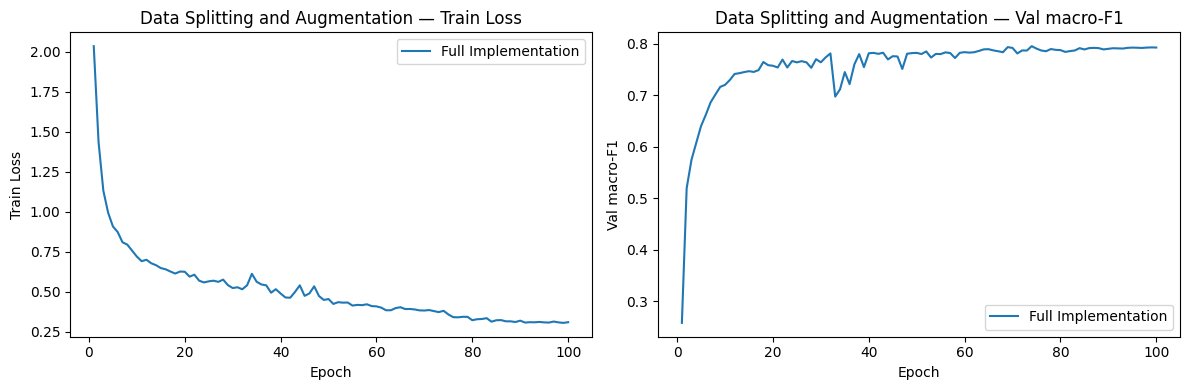

In [ ]:
# Compare: no weight decay (cosine, Section 4) vs two WD values
plot_curves(
    histories=[hist8],
    labels=['Full Implementation'],
    title='Data Splitting and Augmentation'
)

In [ ]:
val_f1 = hist8.get("val_f1")

if val_f1 is None:
    print("No val_f1 found in this run.")
else:
    val_f1_clean = [x for x in val_f1 if x is not None and x == x]  # remove None/NaN
    if not val_f1_clean:
        print("val_f1 exists but has no valid values.")
    else:
        final_val_f1 = val_f1_clean[-1]
        train_loss = hist8.get("train_loss")
        train_loss_clean = [x for x in (train_loss or []) if x is not None and x == x]

        print(f"Final val_f1: {final_val_f1:.6f}")
        if train_loss_clean:
            final_train_loss = train_loss_clean[-1]
            print(f"Final train_loss: {final_train_loss:.6f}")
        else:
            print("train_loss exists but has no valid values.")

Final val_f1: 0.792223
Final train_loss: 0.308890


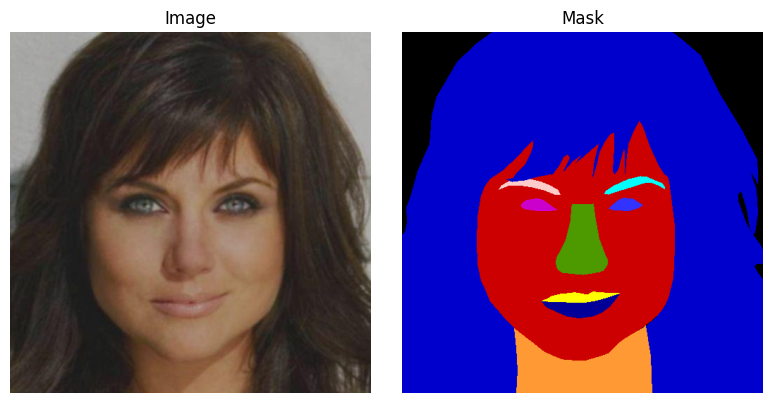

In [ ]:
from PIL import Image
from pathlib import Path

train_dir = Path(globals().get("train_dir", Path(ROOT) / "train"))
if not train_dir.exists():
    raise FileNotFoundError(f"train_dir does not exist: {train_dir}")

images_dir = train_dir / "images"
masks_dir = train_dir / "masks"

img_map = {p.stem: p for p in images_dir.iterdir() if p.is_file()}
mask_map = {p.stem: p for p in masks_dir.iterdir() if p.is_file()}

common_stems = sorted(set(img_map) & set(mask_map))
if not common_stems:
    raise FileNotFoundError(f"No matched image/mask pairs in:\n{images_dir}\n{masks_dir}")

stem = common_stems[0]  # first pair (no augmentation, no random sampling)
img_p = img_map[stem]
mask_p = mask_map[stem]

img = Image.open(img_p).convert("RGB")
mask = Image.open(mask_p)

fig, axes = plt.subplots(1, 2, figsize=(8, 4))

axes[0].imshow(img)
axes[0].set_title(f"Image")
axes[0].axis("off")

axes[1].imshow(mask, cmap="tab20")
axes[1].set_title(f"Mask")
axes[1].axis("off")

plt.tight_layout()
plt.show()


Sample: e0d6be407f224ab6bc3fcba2e762acb0


/tmp/ipykernel_752503/1951073633.py:44: UserWarning: Argument(s) 'value, mask_value' are not valid for transform ShiftScaleRotate
  A.ShiftScaleRotate(


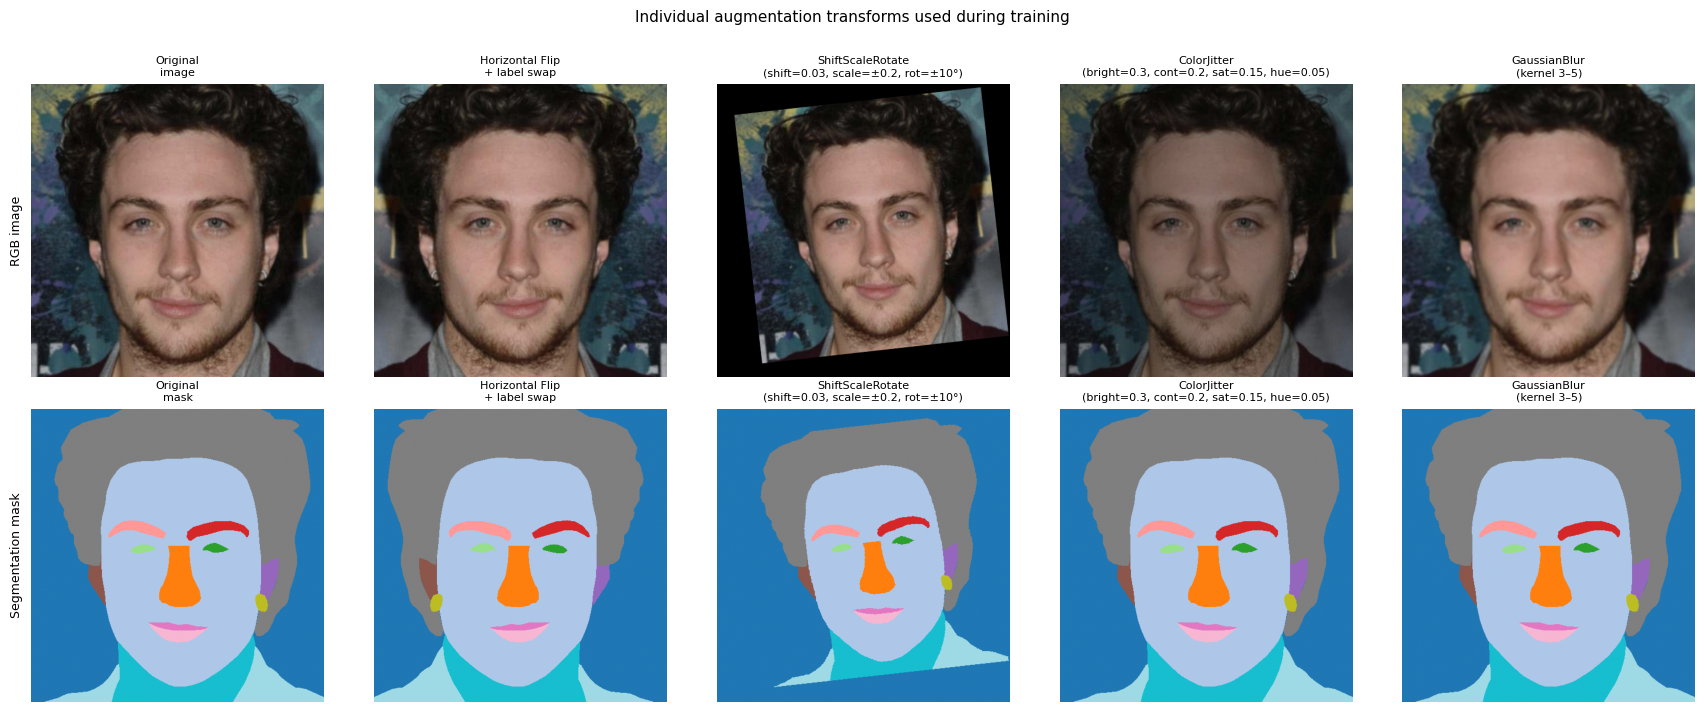

In [3]:

import sys, random
import cv2
import numpy as np
import matplotlib.pyplot as plt
import albumentations as A
from PIL import Image
from pathlib import Path

sys.path.insert(0, str(Path(ROOT)))
from augment import flip_with_label_swap

# ── Config ───────────────────────────────────────────────────────────────────
SEED = 0   # set None for a different sample each run

# ── Load a sample image/mask pair ────────────────────────────────────────────
train_dir  = Path(ROOT) / "train"
img_map    = {p.stem: p for p in (train_dir / "images").iterdir() if p.is_file()}
mask_map   = {p.stem: p for p in (train_dir / "masks").iterdir()  if p.is_file()}
stems      = sorted(set(img_map) & set(mask_map))

rng   = random.Random(SEED)
stem  = rng.choice(stems)
print(f"Sample: {stem}")

img_orig  = np.array(Image.open(img_map[stem]).convert("RGB"))
mask_orig = np.array(Image.open(mask_map[stem])).astype(np.int64)

# ── Define each augmentation used during training (applied in isolation) ──────
def apply_album(transform, img, mask):
    out = transform(image=img.copy(), mask=mask.copy().astype(np.int32))
    return out["image"], out["mask"].astype(np.int64)

if SEED is not None:
    np.random.seed(SEED)

aug_steps = [
    (
        "Horizontal Flip\n+ label swap",
        *flip_with_label_swap(img_orig.copy(), mask_orig.copy(), p=1.0),
    ),
    (
        "ShiftScaleRotate\n(shift=0.03, scale=±0.2, rot=±10°)",
        *apply_album(
            A.ShiftScaleRotate(
                shift_limit=0.03, scale_limit=0.20, rotate_limit=10,
                border_mode=cv2.BORDER_CONSTANT, value=0, mask_value=0, p=1.0,
            ),
            img_orig, mask_orig,
        ),
    ),
    (
        "ColorJitter\n(bright=0.3, cont=0.2, sat=0.15, hue=0.05)",
        *apply_album(
            A.ColorJitter(brightness=0.3, contrast=0.2, saturation=0.15, hue=0.05, p=1.0),
            img_orig, mask_orig,
        ),
    ),
    (
        "GaussianBlur\n(kernel 3–5)",
        *apply_album(
            A.GaussianBlur(blur_limit=(3, 5), p=1.0),
            img_orig, mask_orig,
        ),
    ),
]

# ── Plot ─────────────────────────────────────────────────────────────────────
n_cols = len(aug_steps) + 1
fig, axes = plt.subplots(2, n_cols, figsize=(3.5 * n_cols, 7))

def show(ax, arr, title, cmap=None):
    ax.imshow(arr, cmap=cmap)
    ax.set_title(title, fontsize=8)
    ax.axis("off")

show(axes[0, 0], img_orig,  "Original\nimage")
show(axes[1, 0], mask_orig, "Original\nmask",  cmap="tab20")

for col, (title, img_aug, mask_aug) in enumerate(aug_steps, start=1):
    show(axes[0, col], img_aug,  title)
    show(axes[1, col], mask_aug, title, cmap="tab20")

# row labels
for row, label in enumerate(["RGB image", "Segmentation mask"]):
    axes[row, 0].set_ylabel(label, fontsize=9, rotation=90, labelpad=6)
    axes[row, 0].axis("on")
    axes[row, 0].set_xticks([]); axes[row, 0].set_yticks([])
    for spine in axes[row, 0].spines.values():
        spine.set_visible(False)

fig.suptitle("Individual augmentation transforms used during training", fontsize=11, y=1.01)
fig.tight_layout()
plt.show()


Loaded split 'seed42_vr0.1': 900 train / 100 val


,class_id,class_name,train_samples,val_samples,train_sample_share,val_sample_share,sample_share_gap,train_pixel_share,val_pixel_share,pixel_share_gap,train_mean_area_when_present,val_mean_area_when_present
0,10,mouth,560,68,62.222,68.0,5.778,0.321,0.323,0.001,0.517,0.474
1,18,cloth,520,62,57.778,62.0,4.222,3.437,3.603,0.166,5.949,5.811
2,15,ear_r,241,31,26.778,31.0,4.222,0.251,0.283,0.032,0.937,0.913
3,5,r_eye,883,99,98.111,99.0,0.889,0.221,0.223,0.002,0.225,0.225
4,4,l_eye,886,99,98.444,99.0,0.556,0.223,0.226,0.003,0.227,0.228
5,11,u_lip,895,100,99.444,100.0,0.556,0.420,0.409,-0.011,0.423,0.409
6,12,l_lip,896,100,99.556,100.0,0.444,0.683,0.674,-0.009,0.686,0.674
7,13,hair,873,97,97.000,97.0,0.000,31.476,31.967,0.492,32.449,32.956
8,0,background,900,100,100.000,100.0,0.000,28.949,29.177,0.227,28.949,29.177
9,2,nose,900,100,100.000,100.0,0.000,2.066,2.028,-0.038,2.066,2.028


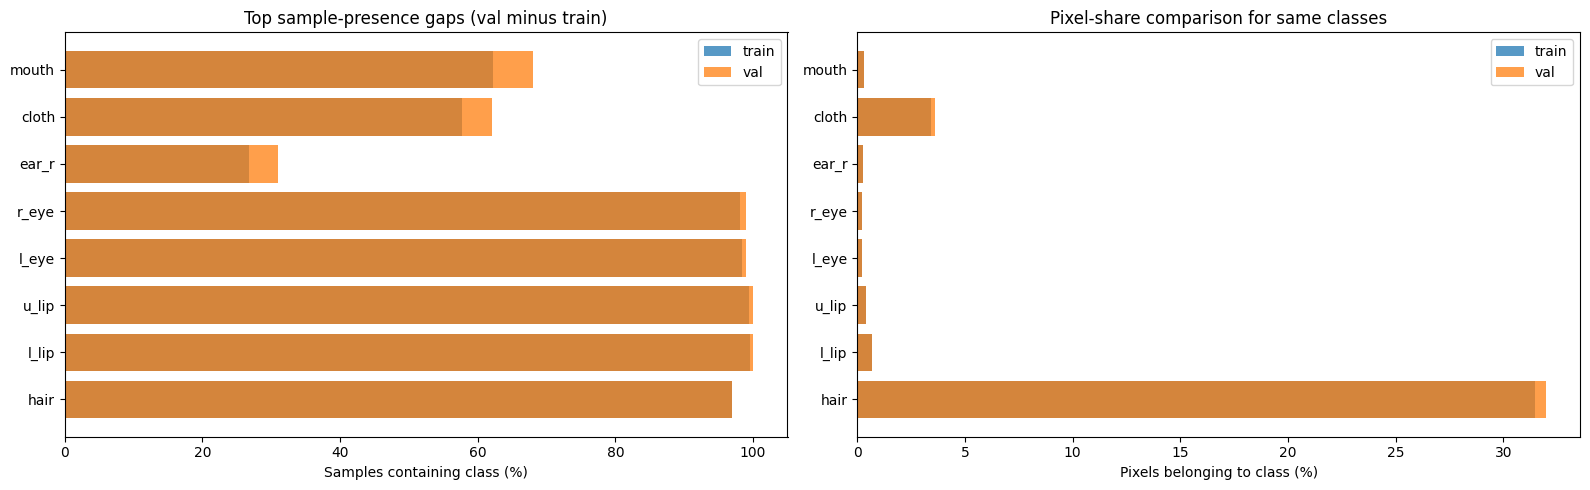

No obvious component-level train/val skew found under the current heuristic.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image

from palette import rgb_to_label, NUM_CLASSES
from split_utils import load_list

CLASS_NAMES = [
    "background", "skin", "nose", "eye_g", "l_eye", "r_eye", "l_brow", "r_brow",
    "l_ear", "r_ear", "mouth", "u_lip", "l_lip", "hair", "hat", "ear_r",
    "neck_l", "neck", "cloth",
]

train_dir = Path(globals().get("train_dir", Path(ROOT) / "train"))
img_dir = train_dir / "images"
mask_dir = train_dir / "masks"
splits_dir = Path(globals().get("splits_dir", Path(ROOT) / "splits"))
split_tag = globals().get("split_tag", "seed42_vr0.1")
train_split_path = splits_dir / f"train_{split_tag}.txt"
val_split_path = splits_dir / f"val_{split_tag}.txt"

if not train_split_path.exists() or not val_split_path.exists():
    raise FileNotFoundError(
        f"Split files not found:\n  {train_split_path}\n  {val_split_path}\n"
        "Set `split_tag` or `splits_dir` to the saved split you want to inspect."
    )

train_files = load_list(train_split_path)
val_files = load_list(val_split_path)
print(f"Loaded split '{split_tag}': {len(train_files)} train / {len(val_files)} val")

mask_lookup = {
    p.stem: p for p in mask_dir.iterdir()
    if p.is_file() and p.suffix.lower() in {".png", ".jpg", ".jpeg"}
}


def analyse_split(file_list):
    pixel_counts = np.zeros(NUM_CLASSES, dtype=np.int64)
    sample_counts = np.zeros(NUM_CLASSES, dtype=np.int64)
    sample_ratios = {cls_id: [] for cls_id in range(NUM_CLASSES)}
    top_files = {cls_id: [] for cls_id in range(NUM_CLASSES)}

    for fn in file_list:
        stem = Path(fn).stem
        labels = rgb_to_label(np.array(Image.open(mask_lookup[stem]).convert("RGB"), dtype=np.uint8))
        counts = np.bincount(labels.reshape(-1), minlength=NUM_CLASSES)
        pixel_counts += counts

        present = counts > 0
        sample_counts += present.astype(np.int64)

        ratios = counts / counts.sum()
        for cls_id in np.flatnonzero(present):
            ratio = float(ratios[cls_id])
            sample_ratios[cls_id].append(ratio)
            top_files[cls_id].append((ratio, fn))

    for cls_id in top_files:
        top_files[cls_id].sort(reverse=True)
        top_files[cls_id] = top_files[cls_id][:10]

    return {
        "pixel_counts": pixel_counts,
        "sample_counts": sample_counts,
        "sample_ratios": sample_ratios,
        "top_files": top_files,
        "num_files": len(file_list),
        "total_pixels": int(pixel_counts.sum()),
    }


train_stats = analyse_split(train_files)
val_stats = analyse_split(val_files)

eps = 1e-12
rows = []
for cls_id, cls_name in enumerate(CLASS_NAMES):
    train_sample_share = train_stats["sample_counts"][cls_id] / max(train_stats["num_files"], 1)
    val_sample_share = val_stats["sample_counts"][cls_id] / max(val_stats["num_files"], 1)
    train_pixel_share = train_stats["pixel_counts"][cls_id] / max(train_stats["total_pixels"], 1)
    val_pixel_share = val_stats["pixel_counts"][cls_id] / max(val_stats["total_pixels"], 1)

    rows.append({
        "class_id": cls_id,
        "class_name": cls_name,
        "train_samples": int(train_stats["sample_counts"][cls_id]),
        "val_samples": int(val_stats["sample_counts"][cls_id]),
        "train_sample_share": train_sample_share,
        "val_sample_share": val_sample_share,
        "sample_share_gap": val_sample_share - train_sample_share,
        "sample_share_ratio": (val_sample_share + eps) / (train_sample_share + eps),
        "train_pixel_share": train_pixel_share,
        "val_pixel_share": val_pixel_share,
        "pixel_share_gap": val_pixel_share - train_pixel_share,
        "pixel_share_ratio": (val_pixel_share + eps) / (train_pixel_share + eps),
        "train_mean_area_when_present": float(np.mean(train_stats["sample_ratios"][cls_id])) if train_stats["sample_ratios"][cls_id] else 0.0,
        "val_mean_area_when_present": float(np.mean(val_stats["sample_ratios"][cls_id])) if val_stats["sample_ratios"][cls_id] else 0.0,
    })

summary_df = pd.DataFrame(rows)
summary_df["train_sample_share"] = summary_df["train_sample_share"] * 100
summary_df["val_sample_share"] = summary_df["val_sample_share"] * 100
summary_df["sample_share_gap"] = summary_df["sample_share_gap"] * 100
summary_df["train_pixel_share"] = summary_df["train_pixel_share"] * 100
summary_df["val_pixel_share"] = summary_df["val_pixel_share"] * 100
summary_df["pixel_share_gap"] = summary_df["pixel_share_gap"] * 100
summary_df["train_mean_area_when_present"] = summary_df["train_mean_area_when_present"] * 100
summary_df["val_mean_area_when_present"] = summary_df["val_mean_area_when_present"] * 100

ranked_df = summary_df.sort_values(
    ["sample_share_gap", "pixel_share_gap", "val_samples"], ascending=False
).reset_index(drop=True)

display(ranked_df[[
    "class_id", "class_name", "train_samples", "val_samples",
    "train_sample_share", "val_sample_share", "sample_share_gap",
    "train_pixel_share", "val_pixel_share", "pixel_share_gap",
    "train_mean_area_when_present", "val_mean_area_when_present",
]].round(3))

plot_df = ranked_df[ranked_df["class_id"] != 0].head(8)
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].barh(plot_df["class_name"], plot_df["train_sample_share"], alpha=0.75, label="train")
axes[0].barh(plot_df["class_name"], plot_df["val_sample_share"], alpha=0.75, label="val")
axes[0].invert_yaxis()
axes[0].set_title("Top sample-presence gaps (val minus train)")
axes[0].set_xlabel("Samples containing class (%)")
axes[0].legend()

axes[1].barh(plot_df["class_name"], plot_df["train_pixel_share"], alpha=0.75, label="train")
axes[1].barh(plot_df["class_name"], plot_df["val_pixel_share"], alpha=0.75, label="val")
axes[1].invert_yaxis()
axes[1].set_title("Pixel-share comparison for same classes")
axes[1].set_xlabel("Pixels belonging to class (%)")
axes[1].legend()
plt.tight_layout()
plt.show()

suspicious = ranked_df[
    (ranked_df["class_id"] != 0)
    & (ranked_df["val_samples"] >= 2)
    & (
        (ranked_df["train_samples"] <= max(2, int(0.02 * len(train_files))))
        | (ranked_df["sample_share_ratio"] >= 2.0)
        | (ranked_df["pixel_share_ratio"] >= 2.0)
    )
].head(5)

if suspicious.empty:
    print("No obvious component-level train/val skew found under the current heuristic.")
else:
    print("Potentially skewed classes and the val files where they occupy the most area:")
    for row in suspicious.itertuples(index=False):
        cls_id = int(row.class_id)
        print(
            f"\n[{cls_id:02d}] {row.class_name}: "
            f"train {row.train_samples}/{len(train_files)} ({row.train_sample_share:.1f}%), "
            f"val {row.val_samples}/{len(val_files)} ({row.val_sample_share:.1f}%), "
            f"pixel gap {row.pixel_share_gap:.3f} pts"
        )
        for ratio, fn in val_stats["top_files"][cls_id][:5]:
            print(f"    {fn:<30} val_area={ratio * 100:.2f}%")


Checkpoint : checkpoints/v2_best.pt
Split      : seed42_vr0.1 (100 val images)
Device     : cuda  |  TTA: True
Loaded 100 samples from /home/msai/qiao0042/QIAO0042/models/acv/facemask/train/images
Global val GT-present F1: 0.7952  (GT-present classes=19)
Mean per-image GT-present F1: 0.8496


,fname,macro_f1_gt_present,gt_present_class_count,worst_classes
0,f7318f1148c34c07a11742d3a41f009d.jpg,0.5482,12,"ear_r:0.00, l_brow:0.00, r_brow:0.00, neck:0.0..."
1,a8ab7da870894f44883bd704fa6e4de5.jpg,0.6889,13,"l_ear:0.00, mouth:0.00, cloth:0.00, neck:0.34,..."
2,46b4e4a7c89447809689caa8081a9102.jpg,0.7325,14,"l_ear:0.00, mouth:0.00, cloth:0.00, ear_r:0.15..."
3,5204e62432ec47d1a9b74e3803ed20a2.jpg,0.7341,14,"r_ear:0.00, l_ear:0.00, cloth:0.00, neck:0.49,..."
4,72e837db7ade4844820e4dd0cd1b93e2.jpg,0.7342,12,"cloth:0.00, neck:0.00, r_brow:0.18, l_brow:0.4..."
5,003a2c2da0ce4f99a57ccddde3757f75.jpg,0.7345,15,"cloth:0.00, l_ear:0.21, neck:0.21, ear_r:0.71,..."
6,65fdc8e94bdb4623a159fe3497666d90.jpg,0.7355,14,"cloth:0.00, ear_r:0.09, neck:0.31, mouth:0.64,..."
7,d56a61a2a8f04072b2cd6af9f5796620.jpg,0.7534,13,"cloth:0.00, neck:0.65, hair:0.71, background:0..."


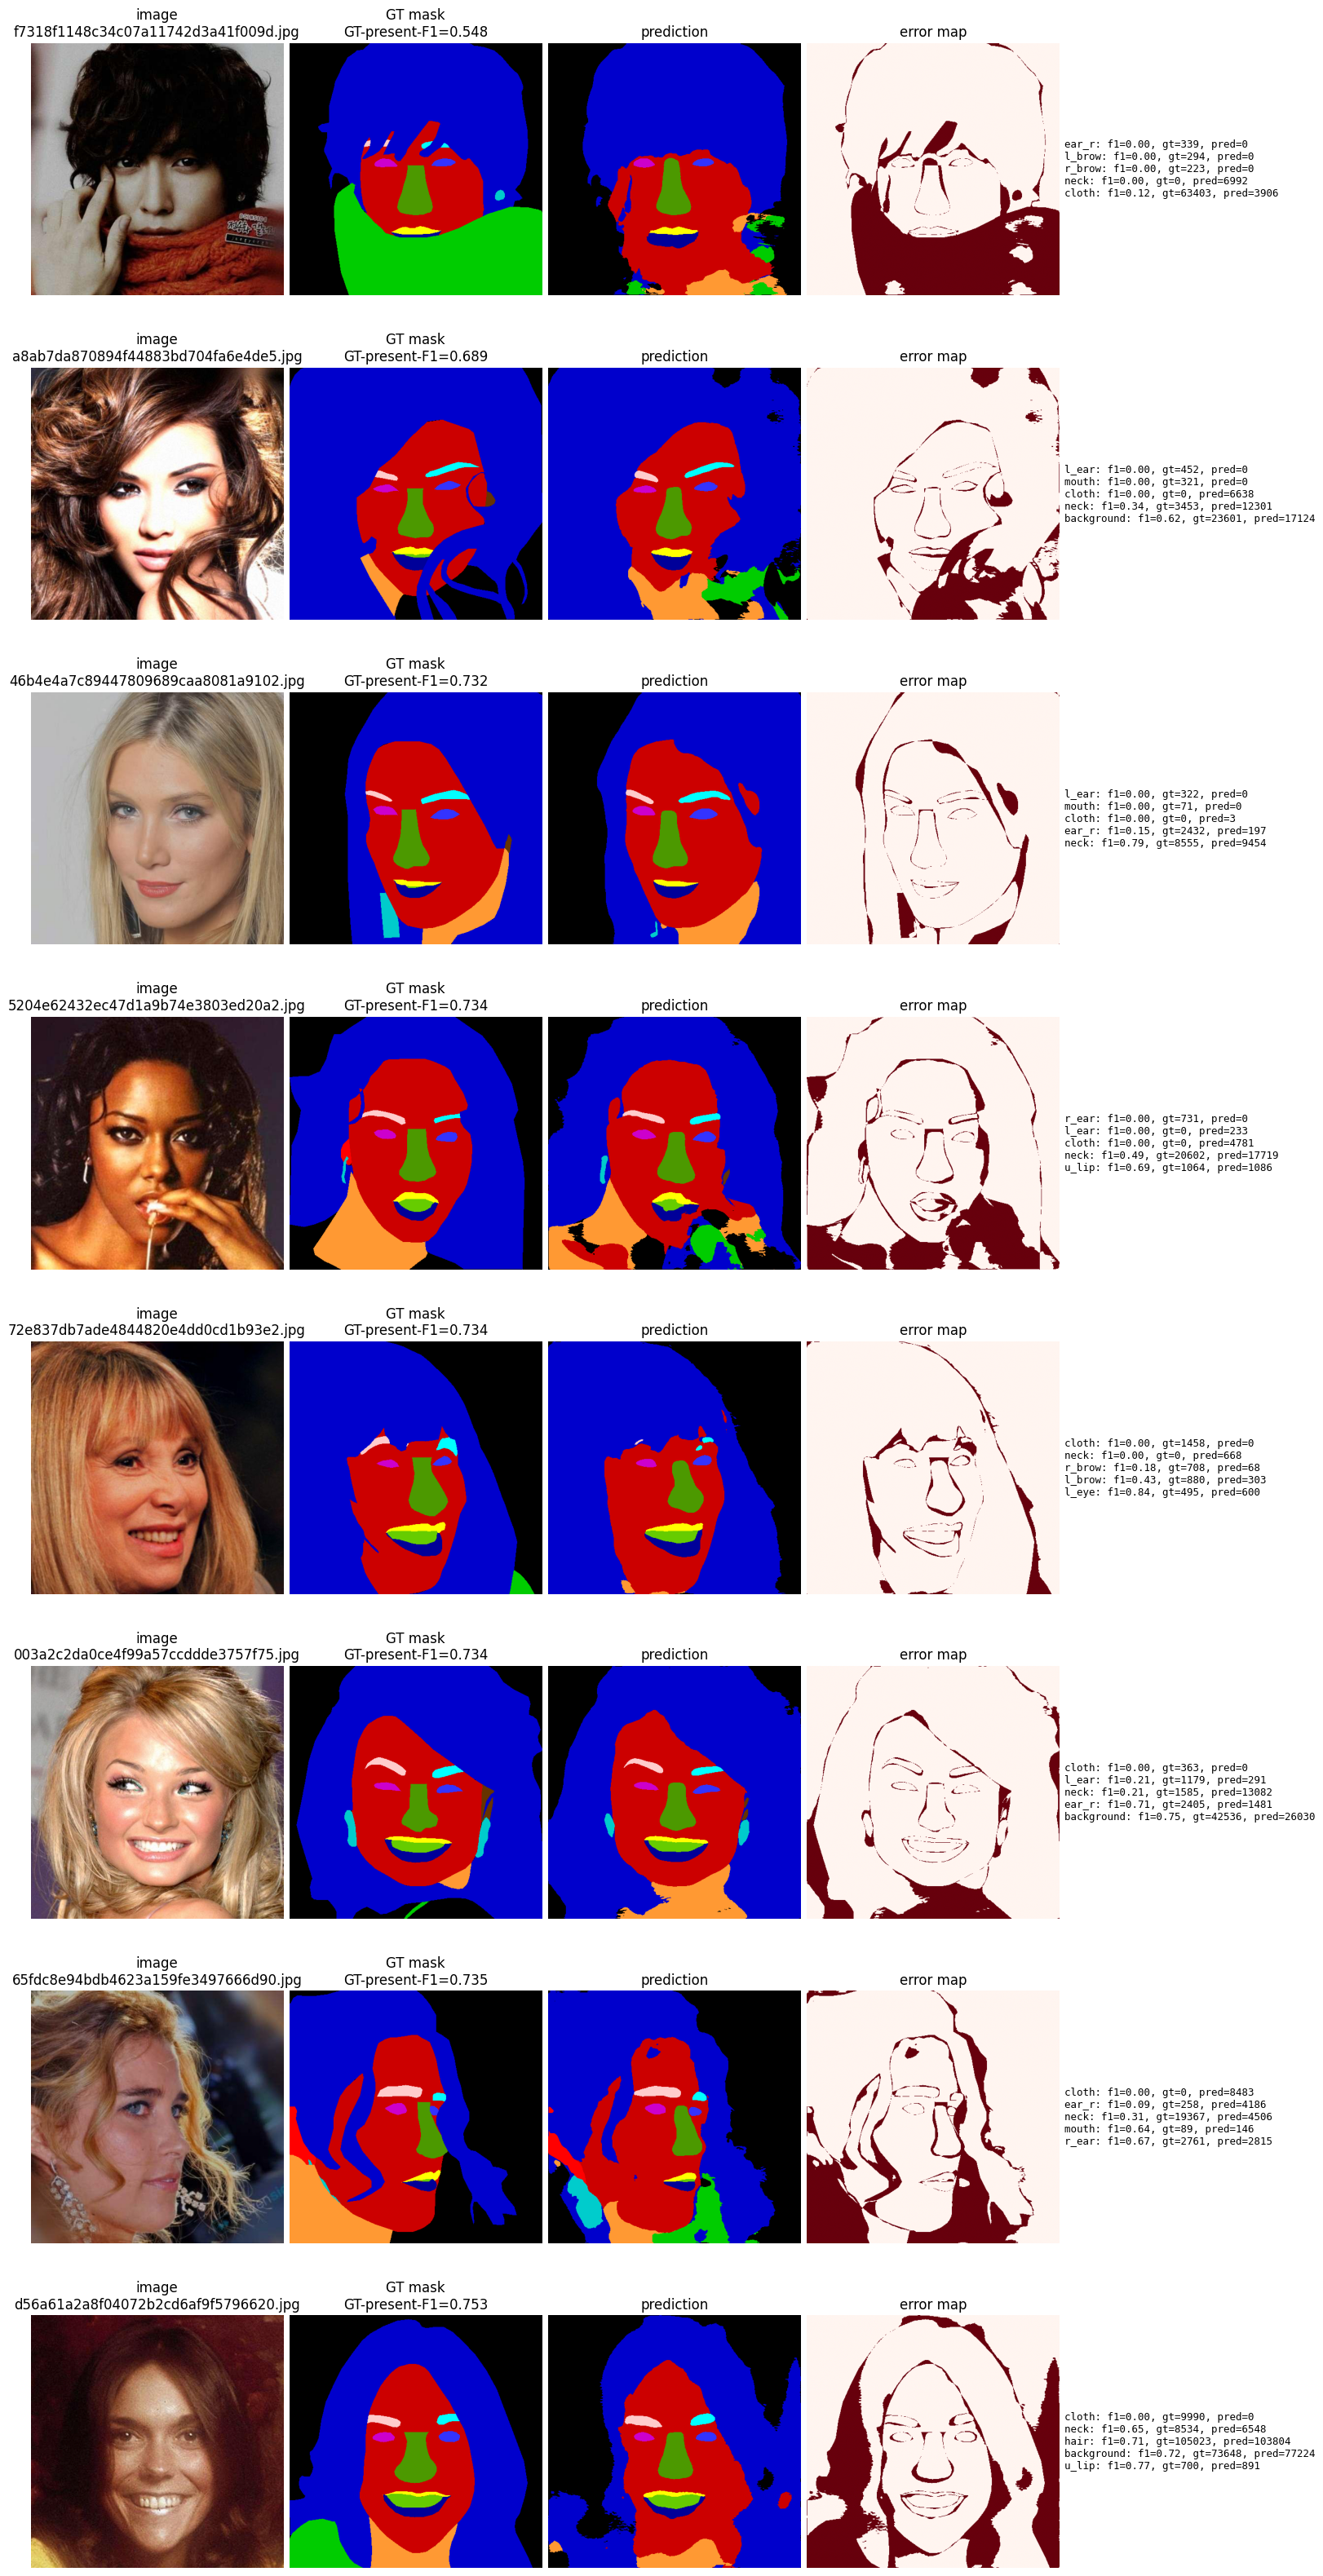

Worst classes on the whole val split:


,class_id,class_name,val_f1,gt_pixels,pred_pixels
0,16,neck_l,0.0000,746,0
1,15,ear_r,0.5146,74163,56144
2,14,hat,0.5515,121439,105658
3,18,cloth,0.6835,944513,815528
4,17,neck,0.8395,1057419,1100659
5,9,r_ear,0.8413,89490,92875
6,6,l_brow,0.8561,102460,110751
7,7,r_brow,0.8612,101267,103348


In [3]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from torch.utils.data import DataLoader

from unet import UNet, UNetV2
from dataset import FaceParsingDataset
from metrics import confusion_matrix, fbeta_present_gt_from_cm
from palette import NUM_CLASSES, label_to_rgb
from split_utils import load_list

CLASS_NAMES = [
    "background", "skin", "nose", "eye_g", "l_eye", "r_eye", "l_brow", "r_brow",
    "l_ear", "r_ear", "mouth", "u_lip", "l_lip", "hair", "hat", "ear_r",
    "neck_l", "neck", "cloth",
]
FLIP_PAIRS = [(4, 5), (6, 7), (8, 9)]

train_dir = Path(globals().get("train_dir", Path(ROOT) / "train"))
img_dir = train_dir / "images"
mask_dir = train_dir / "masks"
splits_dir = Path(globals().get("splits_dir", Path(ROOT) / "splits"))
split_tag = globals().get("split_tag", "seed42_vr0.1")
val_split_path = splits_dir / f"val_{split_tag}.txt"
val_files = load_list(val_split_path)

ckpt_path = globals().get("ckpt_path", "checkpoints/v2_best.pt")
use_tta = globals().get("use_tta", True)
eval_batch_size = globals().get("eval_batch_size", 8)
n_show_worst = globals().get("n_show_worst", 8)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
use_bf16 = device.type == "cuda" and torch.cuda.is_bf16_supported()
amp_dtype = torch.bfloat16 if use_bf16 else torch.float16


def strip_compile_prefix(state_dict):
    return {k.replace("_orig_mod.", "", 1): v for k, v in state_dict.items()}


def build_model_from_ckpt(ckpt, device):
    cfg = ckpt.get("config", {})
    num_classes = cfg.get("num_classes", NUM_CLASSES)
    base_width = cfg.get("base_width", cfg.get("base", 23))
    dropout = cfg.get("dropout", 0.0)
    model_name = str(cfg.get("model", "UNetV2")).lower()

    if "unetv2" in model_name or "base_width" in cfg:
        model = UNetV2(num_classes=num_classes, base=base_width, dropout=dropout).to(device)
    else:
        model = UNet(num_classes=num_classes, base=base_width).to(device)

    model.load_state_dict(strip_compile_prefix(ckpt["model"]))
    if "ema_shadow" in ckpt:
        ema_shadow = strip_compile_prefix(ckpt["ema_shadow"])
        for name, param in model.named_parameters():
            if name in ema_shadow:
                param.data.copy_(ema_shadow[name])
    model.eval()
    return model, cfg


@torch.no_grad()
def predict_probs(model, imgs, use_tta=False):
    with torch.amp.autocast("cuda", dtype=amp_dtype, enabled=device.type == "cuda"):
        logits = model(imgs)
        if isinstance(logits, tuple):
            logits = logits[0]

        if use_tta:
            logits_flip = model(imgs.flip(-1))
            if isinstance(logits_flip, tuple):
                logits_flip = logits_flip[0]
            logits_flip = logits_flip.flip(-1)
            logits_flip_swapped = logits_flip.clone()
            for a, b in FLIP_PAIRS:
                logits_flip_swapped[:, a] = logits_flip[:, b]
                logits_flip_swapped[:, b] = logits_flip[:, a]
            return (torch.softmax(logits, dim=1) + torch.softmax(logits_flip_swapped, dim=1)) * 0.5

        return torch.softmax(logits, dim=1)


def gt_present_f1(cm, beta=1.0):
    score, per_class_f1, present_gt = fbeta_present_gt_from_cm(cm, beta=beta)
    return score, per_class_f1, present_gt


ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)
model, cfg = build_model_from_ckpt(ckpt, device)
print(f"Checkpoint : {ckpt_path}")
print(f"Split      : {split_tag} ({len(val_files)} val images)")
print(f"Device     : {device}  |  TTA: {use_tta}")

val_ds = FaceParsingDataset(img_dir, mask_dir, file_list=val_files, augment=None, cache=False)
val_loader = DataLoader(val_ds, batch_size=eval_batch_size, shuffle=False, num_workers=2, pin_memory=True)

rows = []
cache = {}
global_cm = torch.zeros((NUM_CLASSES, NUM_CLASSES), dtype=torch.int64)

with torch.no_grad():
    for imgs, masks, fnames in val_loader:
        imgs = imgs.to(device, non_blocking=True)
        probs = predict_probs(model, imgs, use_tta=use_tta)
        preds = probs.argmax(dim=1).cpu()
        masks = masks.cpu()

        for img_t, pred, mask, fname in zip(imgs.cpu(), preds, masks, fnames):
            cm = confusion_matrix(pred.unsqueeze(0), mask.unsqueeze(0), num_classes=NUM_CLASSES)
            macro_f1_present, per_class_f1, present_gt = gt_present_f1(cm, beta=1.0)
            gt_counts = torch.bincount(mask.reshape(-1), minlength=NUM_CLASSES)
            pred_counts = torch.bincount(pred.reshape(-1), minlength=NUM_CLASSES)
            present = (gt_counts + pred_counts) > 0

            hard_classes = []
            for cls_id in torch.where(present)[0].tolist():
                hard_classes.append({
                    "class_id": cls_id,
                    "class_name": CLASS_NAMES[cls_id],
                    "f1": float(per_class_f1[cls_id].item()),
                    "gt_pixels": int(gt_counts[cls_id].item()),
                    "pred_pixels": int(pred_counts[cls_id].item()),
                })
            hard_classes = sorted(hard_classes, key=lambda x: (x["f1"], -x["gt_pixels"]))

            rows.append({
                "fname": fname,
                "macro_f1_gt_present": macro_f1_present,
                "gt_present_class_count": int(present_gt.sum().item()),
                "worst_classes": ", ".join(f"{x['class_name']}:{x['f1']:.2f}" for x in hard_classes[:5]),
            })

            cache[fname] = {
                "img": img_t.permute(1, 2, 0).numpy(),
                "mask": mask.numpy(),
                "pred": pred.numpy(),
                "hard_classes": hard_classes,
            }
            global_cm += cm

per_image_df = pd.DataFrame(rows).sort_values(["macro_f1_gt_present"]).reset_index(drop=True)
global_macro, global_per_class, global_present_gt = gt_present_f1(global_cm, beta=1.0)
mean_per_image_macro = float(per_image_df["macro_f1_gt_present"].mean())

print(f"Global val GT-present F1: {global_macro:.4f}  (GT-present classes={int(global_present_gt.sum().item())})")
print(f"Mean per-image GT-present F1: {mean_per_image_macro:.4f}")
display(per_image_df.head(n_show_worst).round(4))

worst = per_image_df.head(n_show_worst)
fig, axes = plt.subplots(len(worst), 4, figsize=(16, 4 * len(worst)))
if len(worst) == 1:
    axes = np.expand_dims(axes, axis=0)

for row_idx, row in enumerate(worst.itertuples(index=False)):
    item = cache[row.fname]
    err = item["pred"] != item["mask"]
    top_text = "\n".join(
        f"{x['class_name']}: f1={x['f1']:.2f}, gt={x['gt_pixels']}, pred={x['pred_pixels']}"
        for x in item["hard_classes"][:5]
    )

    axes[row_idx, 0].imshow(item["img"])
    axes[row_idx, 0].set_title(f"image\n{row.fname}")
    axes[row_idx, 1].imshow(label_to_rgb(item["mask"]))
    axes[row_idx, 1].set_title(f"GT mask\nGT-present-F1={row.macro_f1_gt_present:.3f}")
    axes[row_idx, 2].imshow(label_to_rgb(item["pred"]))
    axes[row_idx, 2].set_title("prediction")
    axes[row_idx, 3].imshow(err, cmap="Reds")
    axes[row_idx, 3].set_title("error map")
    axes[row_idx, 3].text(1.02, 0.5, top_text, transform=axes[row_idx, 3].transAxes, va="center", fontsize=9, family="monospace")

    for col in range(4):
        axes[row_idx, col].axis("off")

plt.tight_layout()
plt.show()

tp = torch.diag(global_cm)
gt_pixels = global_cm.sum(1)
pred_pixels = global_cm.sum(0)
fn_pixels = gt_pixels - tp
fp_pixels = pred_pixels - tp
total_gt = int(gt_pixels.sum().item())
total_fn = int(fn_pixels.sum().item())
total_fp = int(fp_pixels.sum().item())

per_class_df = pd.DataFrame({
    "class_id": list(range(NUM_CLASSES)),
    "class_name": CLASS_NAMES,
    "val_f1": [float(x) for x in global_per_class],
    "gt_pixels": gt_pixels.tolist(),
    "pred_pixels": pred_pixels.tolist(),
    "tp_pixels": tp.tolist(),
    "fn_pixels": fn_pixels.tolist(),
    "fp_pixels": fp_pixels.tolist(),
})
per_class_df["gt_pixel_share_%"] = 100.0 * per_class_df["gt_pixels"] / max(total_gt, 1)
per_class_df["fn_share_of_total_%"] = 100.0 * per_class_df["fn_pixels"] / max(total_fn, 1)
per_class_df["fp_share_of_total_%"] = 100.0 * per_class_df["fp_pixels"] / max(total_fp, 1)
per_class_df["gt_error_rate_%"] = 100.0 * per_class_df["fn_pixels"] / per_class_df["gt_pixels"].clip(lower=1)
per_class_df["pred_error_rate_%"] = 100.0 * per_class_df["fp_pixels"] / per_class_df["pred_pixels"].clip(lower=1)
per_class_df["fn_vs_size_ratio"] = per_class_df["fn_share_of_total_%"] / per_class_df["gt_pixel_share_%"].clip(lower=1e-8)

print("Worst classes on the whole val split:")
display(per_class_df.sort_values("val_f1").reset_index(drop=True).head(8).round(4))

print("Classes contributing the largest share of GT-side errors (false negatives):")
display(
    per_class_df.sort_values("fn_share_of_total_%", ascending=False)
    [[
        "class_id", "class_name", "val_f1", "gt_pixels", "gt_pixel_share_%",
        "fn_pixels", "fn_share_of_total_%", "gt_error_rate_%", "fn_vs_size_ratio"
    ]]
    .reset_index(drop=True)
    .head(10)
    .round(4)
)

print("Classes contributing the largest share of prediction-side errors (false positives):")
display(
    per_class_df.sort_values("fp_share_of_total_%", ascending=False)
    [[
        "class_id", "class_name", "val_f1", "pred_pixels",
        "fp_pixels", "fp_share_of_total_%", "pred_error_rate_%"
    ]]
    .reset_index(drop=True)
    .head(10)
    .round(4)
)


In [4]:
focus_class = globals().get("focus_class", "neck_l")
top_k = globals().get("top_confusions", 8)

if isinstance(focus_class, str):
    if focus_class not in CLASS_NAMES:
        raise ValueError(f"Unknown class name: {focus_class}")
    class_id = CLASS_NAMES.index(focus_class)
else:
    class_id = int(focus_class)
    focus_class = CLASS_NAMES[class_id]

row = global_cm[class_id].clone()
gt_total = int(row.sum().item())
tp = int(row[class_id].item())
fn = gt_total - tp

print(f"Focus class: [{class_id}] {focus_class}")
print(f"GT pixels : {gt_total}")
print(f"TP pixels : {tp}")
print(f"FN pixels : {fn}")

confusion_rows = []
for pred_id, count in enumerate(row.tolist()):
    if count == 0:
        continue
    confusion_rows.append({
        "pred_id": pred_id,
        "pred_class": CLASS_NAMES[pred_id],
        "pixels": count,
        "share_of_gt_%": 100.0 * count / max(gt_total, 1),
        "is_correct": pred_id == class_id,
    })

confusion_df = pd.DataFrame(confusion_rows).sort_values("pixels", ascending=False).reset_index(drop=True)
print("Top prediction targets for this GT class:")
display(confusion_df.head(top_k).round(4))


Focus class: [16] neck_l
GT pixels : 746
TP pixels : 0
FN pixels : 746
Top prediction targets for this GT class:


,pred_id,pred_class,pixels,share_of_gt_%,is_correct
0,17,neck,720,96.5147,False
1,1,skin,15,2.0107,False
2,18,cloth,10,1.3405,False
3,13,hair,1,0.1340,False


Samples involving class [16] neck_l:


,fname,macro_f1_gt_present,gt_pixels,pred_pixels,tp_pixels
0,e7156f9b05c8432cb7a1e5a055853903.jpg,0.8334,11,0,0
1,acd61e3a05414ba6876d3b6c03844f0c.jpg,0.8519,15,0,0
2,d051c2756aad4f679421fc7865317244.jpg,0.7663,720,0,0


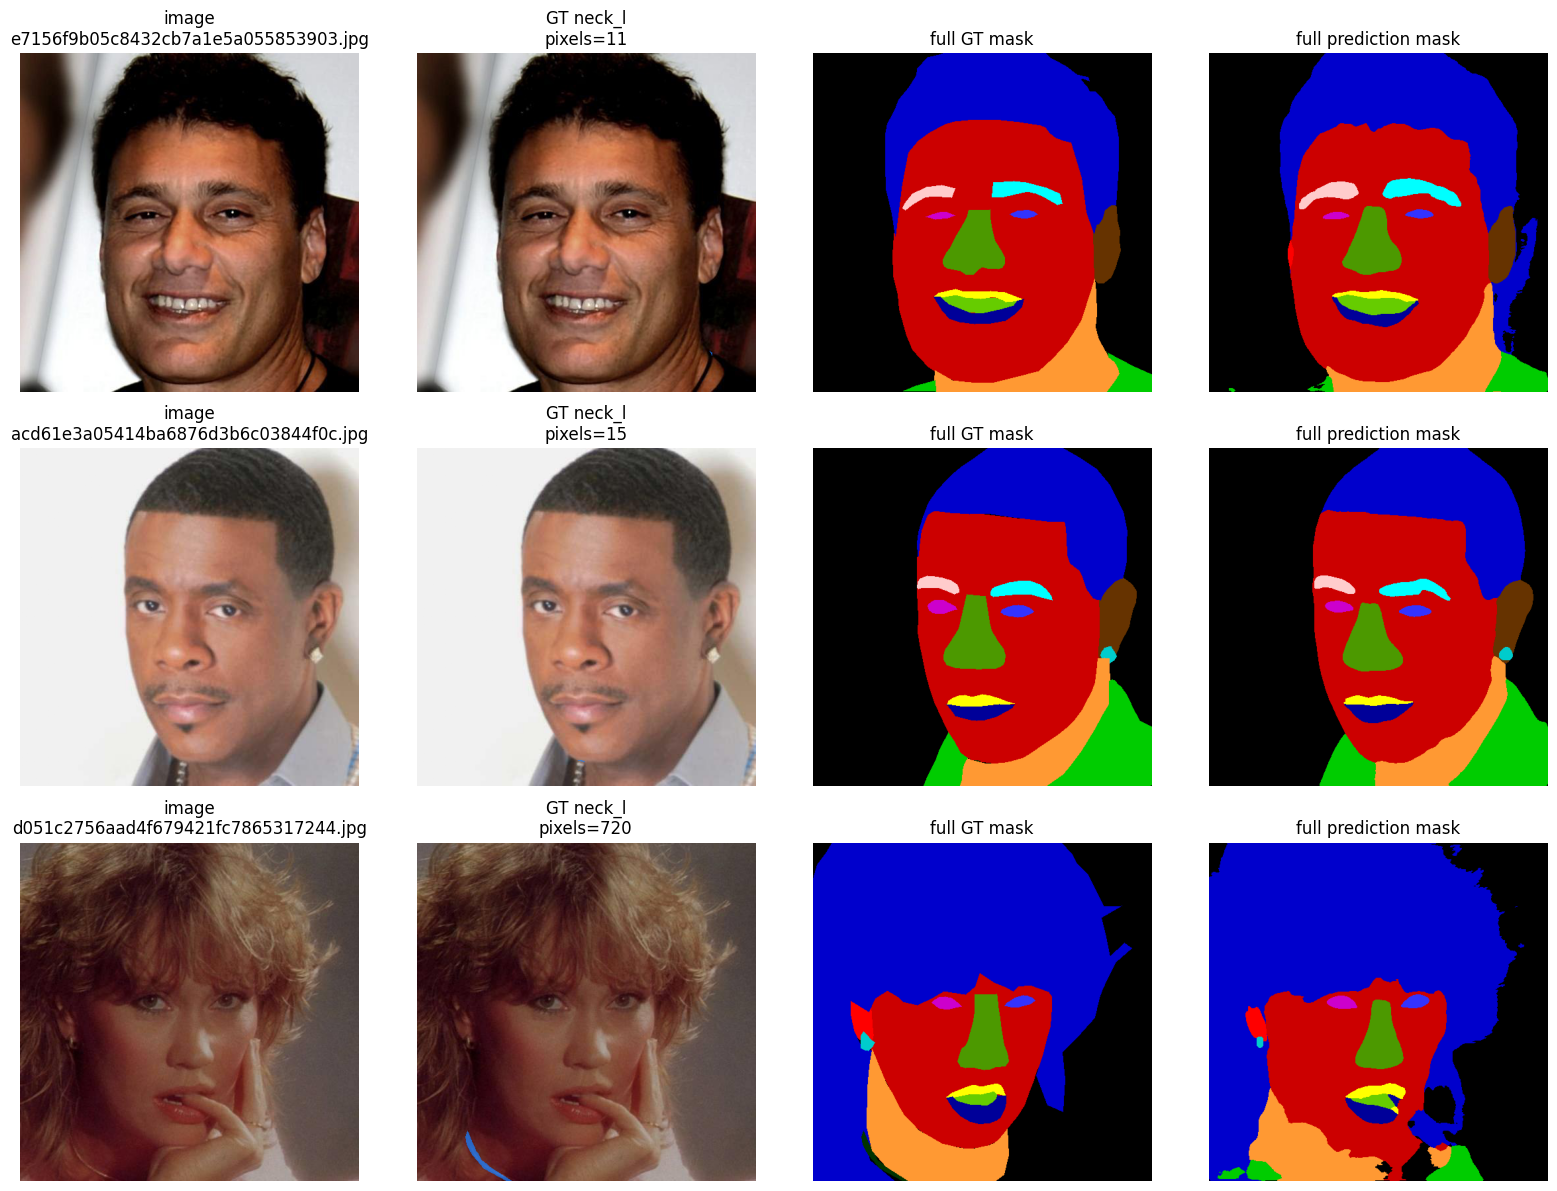

In [12]:
focus_class = globals().get("focus_class", "neck_l")
n_show_focus = globals().get("n_show_focus", 6)

if isinstance(focus_class, str):
    class_id = CLASS_NAMES.index(focus_class)
else:
    class_id = int(focus_class)
    focus_class = CLASS_NAMES[class_id]

focus_rows = []
for row in per_image_df.itertuples(index=False):
    item = cache[row.fname]
    gt_pixels = int((item["mask"] == class_id).sum())
    pred_pixels = int((item["pred"] == class_id).sum())
    tp_pixels = int(((item["mask"] == class_id) & (item["pred"] == class_id)).sum())
    if gt_pixels == 0:
        continue
    focus_rows.append({
        "fname": row.fname,
        "macro_f1_gt_present": row.macro_f1_gt_present,
        "gt_pixels": gt_pixels,
        "pred_pixels": pred_pixels,
        "tp_pixels": tp_pixels,
    })

focus_df = pd.DataFrame(focus_rows).sort_values(["tp_pixels", "gt_pixels", "macro_f1_gt_present"]).reset_index(drop=True)
print(f"Samples involving class [{class_id}] {focus_class}:")
display(focus_df.head(n_show_focus).round(4))

to_show = focus_df.head(n_show_focus)

def overlay_mask(img, mask, color, alpha=0.75):
    out = img.copy()
    color = np.asarray(color, dtype=np.float32)
    out[mask] = (1 - alpha) * out[mask] + alpha * color
    return np.clip(out, 0.0, 1.0)

fig, axes = plt.subplots(len(to_show), 4, figsize=(16, 4 * len(to_show)))
if len(to_show) == 1:
    axes = np.expand_dims(axes, axis=0)

for row_idx, row in enumerate(to_show.itertuples(index=False)):
    item = cache[row.fname]
    gt_focus = item["mask"] == class_id
    pred_focus = item["pred"] == class_id

    axes[row_idx, 0].imshow(item["img"])
    axes[row_idx, 0].set_title(f"image\n{row.fname}")
    axes[row_idx, 1].imshow(overlay_mask(item["img"], gt_focus, color=[0.1, 0.5, 1.0]))
    axes[row_idx, 1].set_title(f"GT {focus_class}\npixels={row.gt_pixels}")
    axes[row_idx, 2].imshow(label_to_rgb(item["mask"]))
    axes[row_idx, 2].set_title("full GT mask")
    axes[row_idx, 3].imshow(label_to_rgb(item["pred"]))
    axes[row_idx, 3].set_title("full prediction mask")

    for col in range(4):
        axes[row_idx, col].axis("off")

plt.tight_layout()
plt.show()
